In [31]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt

In [32]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("puneet6060/intel-image-classification")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\ramch\.cache\kagglehub\datasets\puneet6060\intel-image-classification\versions\2


For checking the status of downloaded data!

In [33]:
import os
os.listdir(path)

['seg_pred', 'seg_test', 'seg_train']

In [34]:
os.listdir(os.path.join(path,"seg_train"))

['seg_train']

Selecting the file route

In [35]:
train_data = os.path.join(path, "seg_train")
test_data = os.path.join(path, "seg_test")

In [36]:
import pickle as pkl
from pickle import TRUE

In [37]:
training_data = keras.utils.image_dataset_from_directory(
    train_data,
    image_size=(64, 64),
    batch_size=32,
    shuffle=True
)

Found 14034 files belonging to 1 classes.


In [38]:
testing_data = keras.utils.image_dataset_from_directory(
    test_data,
    image_size=(64, 64),
    batch_size=32,
    shuffle=False
)

Found 3000 files belonging to 1 classes.


Optional = '''VISUALISATION

In [39]:
class_name = training_data.class_names
print(class_name)

['seg_train']


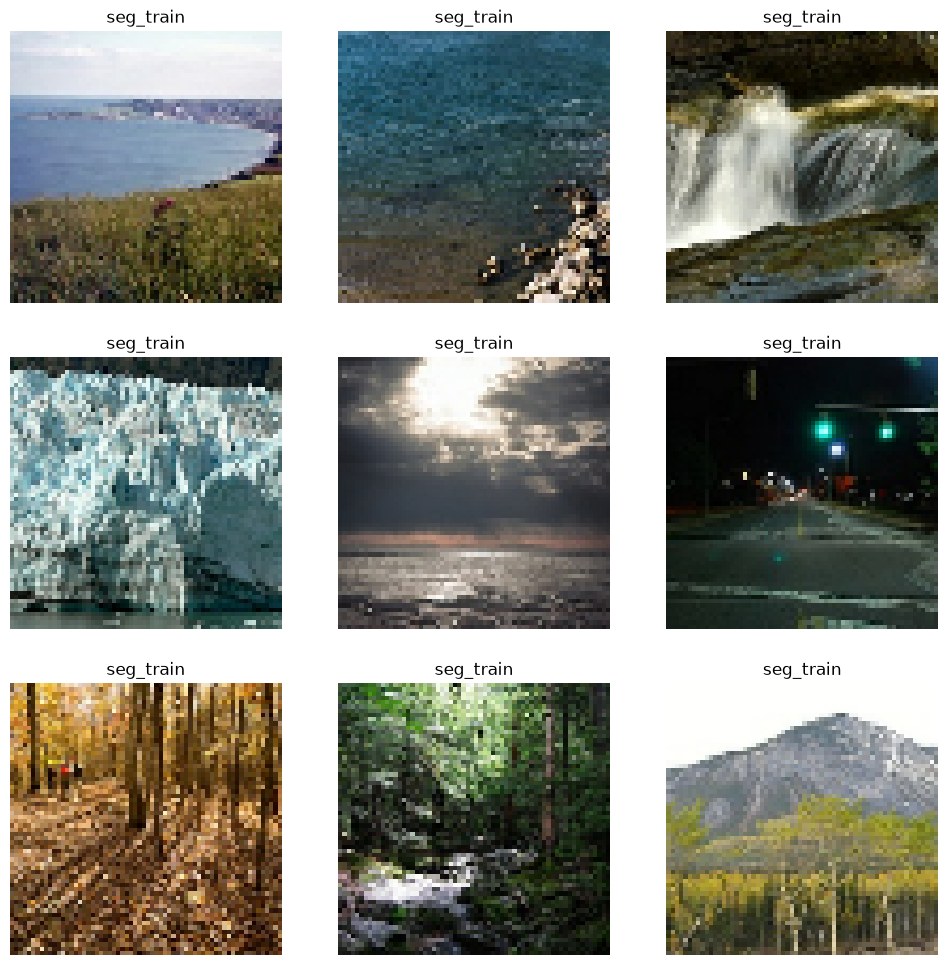

In [40]:
plt.figure(figsize=(12, 12))
for images, labels in training_data.take(1):
    for i in range(9):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_name[labels[i]])
        plt.axis("off")
plt.show()

VISUILASATION '''

In [44]:
model = keras.Sequential([
    keras.layers.Input(shape=(64, 64, 3)),
    keras.layers.Rescaling(1.0 / 255),
    keras.layers.Conv2D(32, (2, 2), activation="relu"),
    keras.layers.MaxPooling2D((2, 2)),
    keras.layers.Conv2D(15, (2, 2), activation="tanh"),
    keras.layers.MaxPooling2D((2, 2)),
    keras.layers.Flatten(),
    keras.layers.Dense(64, activation="sigmoid"),
    keras.layers.Dense(32, activation="relu"),
    keras.layers.Dense(6, activation="softmax")
])
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 63, 63, 32)     │           416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 30, 30, 15)     │         1,935 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 15, 15, 15)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 3375)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │       216,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 6)              │           198 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 220,693 (862.08 KB)

 Trainable params: 220,693 (862.08 KB)

 Non-trainable params: 0 (0.00 B)

In [45]:
model.compile(
    optimizer=keras.optimizers.Adam(),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

#model training start here...

In [47]:
History = model.fit(training_data,epochs = 7)

Epoch 1/7


c:\Users\ramch\OneDrive\Desktop\DL CLASS\deepl_env\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


439/439 ━━━━━━━━━━━━━━━━━━━━ 54s 116ms/step - accuracy: 0.9979 - loss: 0.0116
Epoch 2/7
439/439 ━━━━━━━━━━━━━━━━━━━━ 15s 35ms/step - accuracy: 1.0000 - loss: 1.1639e-05
Epoch 3/7
439/439 ━━━━━━━━━━━━━━━━━━━━ 13s 30ms/step - accuracy: 1.0000 - loss: 3.2353e-06
Epoch 4/7
439/439 ━━━━━━━━━━━━━━━━━━━━ 15s 34ms/step - accuracy: 1.0000 - loss: 1.4883e-06
Epoch 5/7
439/439 ━━━━━━━━━━━━━━━━━━━━ 19s 44ms/step - accuracy: 1.0000 - loss: 7.8189e-07
Epoch 6/7
439/439 ━━━━━━━━━━━━━━━━━━━━ 19s 41ms/step - accuracy: 1.0000 - loss: 4.8669e-07
Epoch 7/7
439/439 ━━━━━━━━━━━━━━━━━━━━ 19s 43ms/step - accuracy: 1.0000 - loss: 3.5837e-07


Text(0.5, 1.0, 'loss of my model')

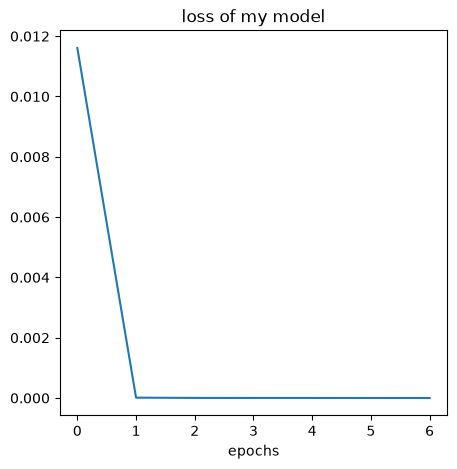

In [51]:
plt.figure(figsize = (5,5))
plt.plot(History.history["loss"])
plt.xlabel("epochs")
# plt.ylabel("loss")
plt.title("loss of my model")
